# Q4 Momentum & Damping Analysis (2018-2022)
**Objective:** Calculate the YoY growth of Q4 (Oct-Dec) to use as a momentum signal for 2023-2024, with a damping factor of 0.05 applied for 2024.

Q4 Historical Totals:
           Revenue          COGS
Date                            
2012  3.226946e+08  2.567640e+08
2013  2.967470e+08  2.599743e+08
2014  3.180331e+08  2.787897e+08
2015  3.473922e+08  3.088298e+08
2016  3.380817e+08  2.981898e+08
2017  3.164216e+08  2.750732e+08
2018  2.297591e+08  1.976044e+08
2019  1.754977e+08  1.530604e+08
2020  1.575489e+08  1.376156e+08
2021  1.667345e+08  1.521077e+08
2022  1.798495e+08  1.625576e+08

Q4 YoY Growth (%):
        Revenue       COGS
Date                      
2012        NaN        NaN
2013  -8.040910   1.250304
2014   7.173125   7.237391
2015   9.231478  10.775183
2016  -2.680116  -3.445247
2017  -6.406766  -7.752328
2018 -27.388294 -28.162984
2019 -23.616656 -22.542010
2020 -10.227362 -10.090626
2021   5.830338  10.530852
2022   7.865754   6.870051

Final Momentum Signal (Q4 22 / Q4 21):
Revenue Multiplier: 1.0787
COGS Multiplier: 1.0687


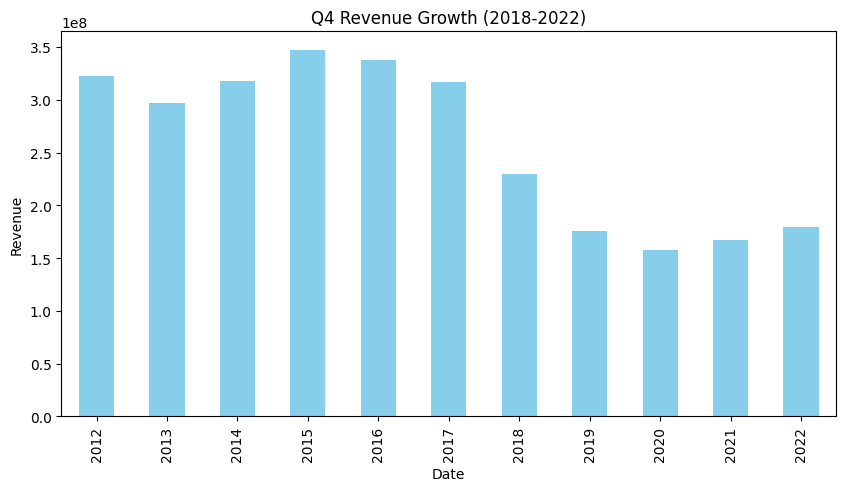

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.config import Config

sales = pd.read_parquet(Config.PROCESSED_DATA_DIR / "sales.parquet")
sales['Date'] = pd.to_datetime(sales['Date'])

# Filter Q4 (Oct, Nov, Dec)
sales['is_q4'] = sales['Date'].dt.month.isin([10, 11, 12])
q4_stats = sales[sales['is_q4']].groupby(sales['Date'].dt.year)[['Revenue', 'COGS']].sum()

print("Q4 Historical Totals:")
print(q4_stats)

# Calculate Q4 YoY Growth
q4_growth = q4_stats.pct_change() * 100
print("\nQ4 YoY Growth (%):")
print(q4_growth)

last_q4_growth_rev = q4_stats.loc[2022, 'Revenue'] / q4_stats.loc[2021, 'Revenue']
last_q4_growth_cogs = q4_stats.loc[2022, 'COGS'] / q4_stats.loc[2021, 'COGS']

print(f"\nFinal Momentum Signal (Q4 22 / Q4 21):")
print(f"Revenue Multiplier: {last_q4_growth_rev:.4f}")
print(f"COGS Multiplier: {last_q4_growth_cogs:.4f}")

# Visualization of Q4 Momentum
plt.figure(figsize=(10, 5))
q4_stats['Revenue'].plot(kind='bar', color='skyblue')
plt.title("Q4 Revenue Growth (2018-2022)")
plt.ylabel("Revenue")
plt.show()